# House Price Prediction - Comprehensive Pipeline

This notebook covers the Exploratory Data Analysis (EDA), Feature Engineering, and Model Comparison for the housing price prediction project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", palette="pastel")

## 1. Data Loading

In [2]:
df = pd.read_csv('../data/raw/housing.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (545, 13)


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price
0,8694,3,1,1,yes,no,no,yes,yes,0,no,semi-furnished,3519089
1,3030,5,1,1,no,no,no,no,yes,2,yes,unfurnished,1680592
2,8340,4,2,1,yes,no,no,yes,yes,2,no,semi-furnished,3605673
3,6172,4,2,3,no,no,no,no,no,2,no,semi-furnished,2897852
4,6341,3,3,4,yes,no,yes,yes,no,0,yes,unfurnished,2998596


## 2. Exploratory Data Analysis (EDA)

In [10]:
df.shape

(545, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              545 non-null    int64 
 1   bedrooms          545 non-null    int64 
 2   bathrooms         545 non-null    int64 
 3   stories           545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
 12  price             545 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.describe()

,area,bedrooms,bathrooms,stories,parking,price
count,545.000000,545.000000,545.000000,545.000000,545.000000,5.450000e+02
mean,8280.135780,2.987156,2.469725,2.537615,1.368807,3.604797e+06
std,3869.896802,1.369917,1.089514,1.133934,1.118749,1.360103e+06
min,1516.000000,1.000000,1.000000,1.000000,0.000000,1.024399e+06
25%,5015.000000,2.000000,2.000000,2.000000,0.000000,2.451866e+06
50%,8179.000000,3.000000,3.000000,3.000000,1.000000,3.519089e+06
75%,11643.000000,4.000000,3.000000,4.000000,2.000000,4.800971e+06
max,14978.000000,5.000000,4.000000,4.000000,3.000000,6.145621e+06


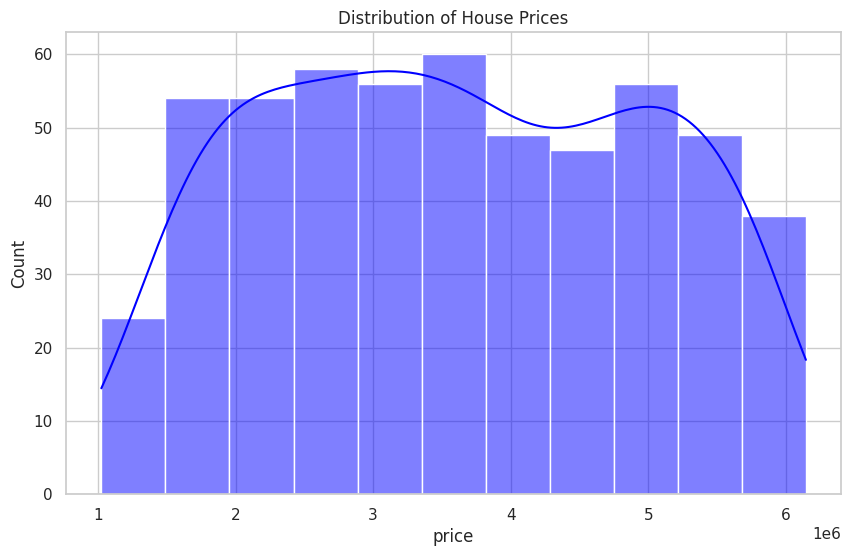

In [5]:
# Distribution of Price
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.show()

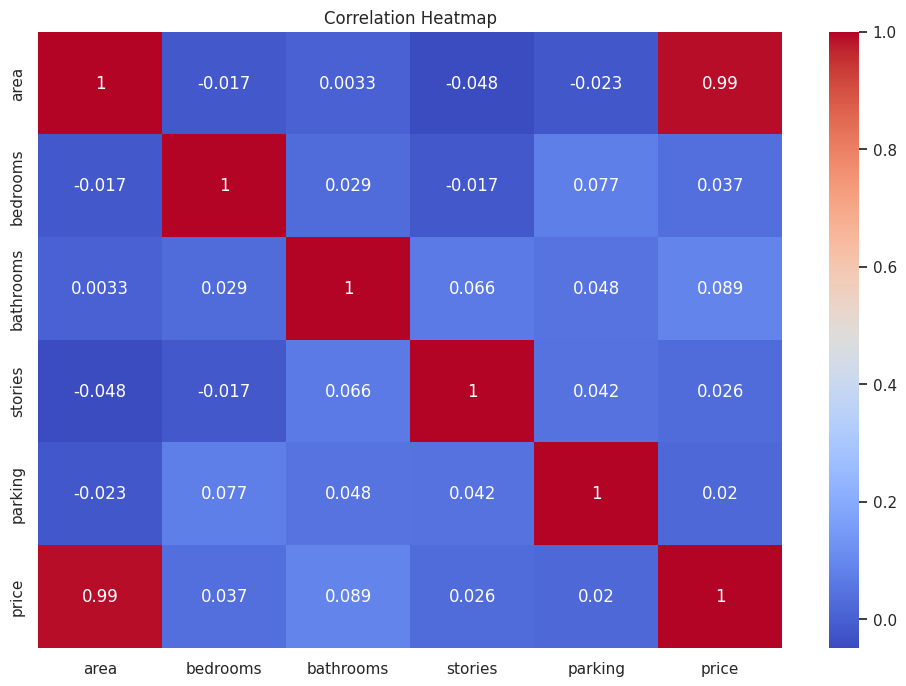

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 3. Feature Engineering & Visualizations

In [7]:
# Relationship between Area and Price
fig = px.scatter(df, x="area", y="price", color="airconditioning", 
                 size="bedrooms", hover_data=['parking'],
                 title="Price vs Area with Air Conditioning Context")
fig.show()

## 4. Model Comparison

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

X = pd.get_dummies(df.drop('price', axis=1), drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
    "LightGBM": LGBMRegressor(verbose=-1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} R2 Score: {r2_score(y_test, y_pred):.4f}")

Linear Regression R2 Score: 0.9995
Random Forest R2 Score: 0.9909
XGBoost R2 Score: 0.9960
LightGBM R2 Score: 0.9970
